## Understand the Objective
### This dataset is about competitor pricing analysis per SKU.
### You can answer questions like:
- Which SKUs are highly competitive?
- Where is the price spread high?
- Which products face many competitors?
- Identify pricing pressure SKUs

In [1]:
import pandas as pd
import numpy as np

## Load the Dataset

In [2]:
df=pd.read_csv('datasets/Competitor_Data.csv')

In [3]:
df.head()

,SKU,Avg_Competitor_Price,Lowest_Competitor_Price,Highest_Competitor_Price,Competitor_Count
0,MN-01,$36.90,$31.95,$44.90,9
1,MN-02,$32.50,$27.90,$39.95,8
2,MN-03,$35.20,$29.99,$42.50,7
3,MN-04,$28.40,$24.50,$35.90,6
4,MN-05,$23.90,$18.95,-,3


## Initial Inspection

In [4]:
df.shape

(50, 5)

In [5]:
df.columns

Index(['SKU', 'Avg_Competitor_Price', 'Lowest_Competitor_Price',
       'Highest_Competitor_Price', 'Competitor_Count'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   SKU                       50 non-null     object
 1   Avg_Competitor_Price      49 non-null     object
 2   Lowest_Competitor_Price   50 non-null     object
 3   Highest_Competitor_Price  50 non-null     object
 4   Competitor_Count          50 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ KB


In [7]:
df.isnull().sum()

SKU                         0
Avg_Competitor_Price        1
Lowest_Competitor_Price     0
Highest_Competitor_Price    0
Competitor_Count            0
dtype: int64

## Descriptive Statistics

In [8]:
df.describe()

,Competitor_Count
count,50.000000
mean,7.360000
std,1.425139
min,3.000000
25%,6.250000
50%,8.000000
75%,8.000000
max,10.000000


- Average competitor prices
- Min & max prices
- Competitor count distribution

## Converting Data Type

In [9]:
df.dtypes

SKU                         object
Avg_Competitor_Price        object
Lowest_Competitor_Price     object
Highest_Competitor_Price    object
Competitor_Count             int64
dtype: object

In [10]:
df = df.replace(r'[\$,]', '', regex=True)

In [11]:
df.dtypes

SKU                         object
Avg_Competitor_Price        object
Lowest_Competitor_Price     object
Highest_Competitor_Price    object
Competitor_Count             int64
dtype: object

In [12]:
df['Avg_Competitor_Price'] = pd.to_numeric(df['Avg_Competitor_Price'], errors='coerce').fillna(0).astype(int)
df['Lowest_Competitor_Price'] = pd.to_numeric(df['Lowest_Competitor_Price'], errors='coerce').fillna(0).astype(int)
df['Highest_Competitor_Price'] = pd.to_numeric(df['Highest_Competitor_Price'], errors='coerce').fillna(0).astype(int)

In [13]:
df.head()

,SKU,Avg_Competitor_Price,Lowest_Competitor_Price,Highest_Competitor_Price,Competitor_Count
0,MN-01,36,31,44,9
1,MN-02,32,27,39,8
2,MN-03,35,29,42,7
3,MN-04,28,24,35,6
4,MN-05,23,18,0,3


In [14]:
df.isnull().sum()

SKU                         0
Avg_Competitor_Price        0
Lowest_Competitor_Price     0
Highest_Competitor_Price    0
Competitor_Count            0
dtype: int64

In [15]:
df.isna().sum()

SKU                         0
Avg_Competitor_Price        0
Lowest_Competitor_Price     0
Highest_Competitor_Price    0
Competitor_Count            0
dtype: int64

## Price Range

In [16]:
df['Price_Range_difference'] = df['Highest_Competitor_Price'] - df['Lowest_Competitor_Price']

In [17]:
df['Price_Range_difference']

0     13
1     12
2     13
3     11
4    -18
5      9
6     13
7     14
8     11
9     10
10     9
11    10
12    12
13    12
14    11
15    10
16    13
17    12
18    17
19     7
20    11
21    10
22     6
23    10
24    15
25    13
26    13
27    12
28    11
29    15
30    13
31    12
32    12
33    15
34    15
35    13
36    12
37    14
38    12
39    12
40    30
41    30
42     8
43     8
44    14
45    13
46    31
47    35
48    14
49    14
Name: Price_Range_difference, dtype: int32

## Average vs Lowest Difference

In [18]:
df['Avg_vs_Lowest'] = df['Avg_Competitor_Price'] - df['Lowest_Competitor_Price']

In [19]:
df['Avg_vs_Lowest']

0      5
1      5
2      6
3      4
4      5
5      3
6      5
7      6
8      4
9      4
10     3
11     4
12     5
13     4
14     4
15     4
16     5
17     4
18     6
19     3
20     5
21     4
22     2
23     4
24     6
25     5
26     5
27     5
28     4
29     6
30     5
31     5
32   -21
33     6
34     6
35     6
36     5
37     6
38     5
39     5
40    13
41    12
42     3
43    -9
44     6
45     5
46    13
47    14
48     6
49     6
Name: Avg_vs_Lowest, dtype: int32

## Detect Expensive & Cheap Products

In [20]:
df['Price_Category'] = pd.cut(
    df['Avg_Competitor_Price'],
    bins=[0, 20, 30, 50],
    labels=['Low', 'Medium', 'High']
)

In [21]:
df['Price_Category'].isnull().sum()

6

In [22]:
mode_value = df['Price_Category'].mode()[0]
df['Price_Category'] = df['Price_Category'].fillna(mode_value)

In [23]:
df['Price_Category'].isnull().sum()

0

In [24]:
df['Price_Category']

0       High
1       High
2       High
3     Medium
4     Medium
5        Low
6       High
7       High
8        Low
9        Low
10       Low
11    Medium
12    Medium
13    Medium
14    Medium
15       Low
16      High
17    Medium
18      High
19       Low
20    Medium
21    Medium
22       Low
23       Low
24      High
25    Medium
26    Medium
27    Medium
28    Medium
29      High
30    Medium
31    Medium
32    Medium
33      High
34      High
35    Medium
36    Medium
37      High
38    Medium
39    Medium
40    Medium
41    Medium
42       Low
43    Medium
44      High
45    Medium
46    Medium
47    Medium
48      High
49    Medium
Name: Price_Category, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

## Outlier Detection

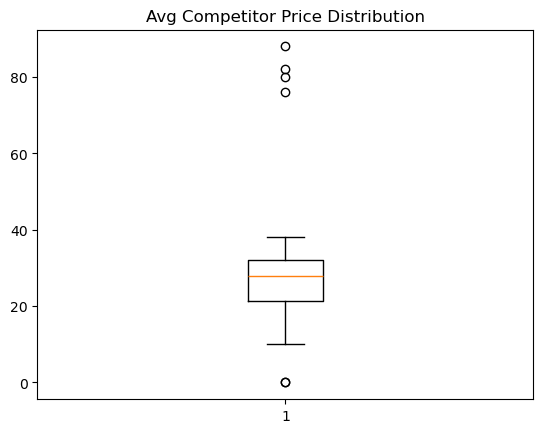

In [25]:
import matplotlib.pyplot as plt

plt.boxplot(df['Avg_Competitor_Price'])
plt.title("Avg Competitor Price Distribution")
plt.show()


# Business Insights

- Which products have high price variation?

In [26]:
df.sort_values('Price_Range_difference', ascending=False).head()

,SKU,Avg_Competitor_Price,Lowest_Competitor_Price,Highest_Competitor_Price,Competitor_Count,Price_Range_difference,Avg_vs_Lowest,Price_Category
47,MN-48,88,74,109,5,35,14,Medium
46,MN-47,80,67,98,6,31,13,Medium
40,MN-41,82,69,99,6,30,13,Medium
41,MN-42,76,64,94,6,30,12,Medium
18,MN-19,38,32,49,7,17,6,High


- Which products are highly competitive (low price range)?

In [27]:
df.sort_values('Price_Range_difference').head()

,SKU,Avg_Competitor_Price,Lowest_Competitor_Price,Highest_Competitor_Price,Competitor_Count,Price_Range_difference,Avg_vs_Lowest,Price_Category
4,MN-05,23,18,0,3,-18,5,Medium
22,MN-23,10,8,14,6,6,2,Low
19,MN-20,12,9,16,6,7,3,Low
42,MN-43,14,11,19,6,8,3,Low
43,MN-44,0,9,17,6,8,-9,Medium


- I cleaned price data by removing currency symbols and handling missing values.
- I created derived features like price range and average-lowest difference to analyze competitor pricing behavior.
- This helped identify products with high pricing volatility and competitive markets.

In [28]:
df.to_csv("cleaned_Competitor_Data.csv", index=False)